In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
employee = pd.read_csv("/content/employee_tasks_dataset_3.csv")
employee.head()

,employee_id,task_id,task_type,task_given_date,days_to_deadline,priority,original_completed_days,actual_hours_to_complete,is_completed,rating,perceived_difficulty,primary_skill_matching,secondary_skill_matching,ternary_skill_matching,volume_metric,dependency_score,error_risk
0,EMP_001,TSK_0000001,Code Review,2024-04-07,20,Low,4.0,26.0,1,5.0,2,0.82,0.41,0.07,3,3,2
1,EMP_001,TSK_0000002,Bug Fix,2026-05-26,20,Low,NaN,NaN,0,NaN,2,0.71,0.45,0.17,2,3,3
2,EMP_001,TSK_0000003,Feature Development,2026-03-04,14,High,NaN,NaN,0,NaN,5,0.69,0.20,0.03,5,2,3
3,EMP_001,TSK_0000004,Feature Development,2024-07-18,18,Medium,2.4,22.4,1,5.0,2,0.69,0.41,0.14,2,2,2
4,EMP_001,TSK_0000005,Code Review,2025-04-09,12,Medium,1.1,8.3,1,5.0,1,0.80,0.37,0.12,1,2,0


In [ ]:
employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   employee_id               200000 non-null  object 
 1   task_id                   200000 non-null  object 
 2   task_type                 200000 non-null  object 
 3   task_given_date           200000 non-null  object 
 4   days_to_deadline          200000 non-null  int64  
 5   priority                  200000 non-null  object 
 6   original_completed_days   155591 non-null  float64
 7   actual_hours_to_complete  155591 non-null  float64
 8   is_completed              200000 non-null  int64  
 9   rating                    155591 non-null  float64
 10  perceived_difficulty      200000 non-null  int64  
 11  primary_skill_matching    200000 non-null  float64
 12  secondary_skill_matching  200000 non-null  float64
 13  ternary_skill_matching    200000 non-null  f

In [ ]:
employee.describe()

,days_to_deadline,original_completed_days,actual_hours_to_complete,is_completed,rating,perceived_difficulty,primary_skill_matching,secondary_skill_matching,ternary_skill_matching,volume_metric,dependency_score,error_risk
count,200000.000000,155591.000000,155591.000000,200000.000000,155591.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,13.985040,3.077531,22.429662,0.777955,4.572395,2.038255,0.714012,0.357455,0.119291,2.429655,1.942565,1.843525
std,5.312644,2.324644,14.813667,0.415622,0.626254,1.142965,0.160131,0.159892,0.087901,1.210735,0.973422,1.083931
min,3.000000,0.500000,0.500000,0.000000,1.100000,0.000000,0.050000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,10.000000,1.400000,11.000000,1.000000,4.200000,1.000000,0.610000,0.240000,0.050000,1.000000,1.000000,1.000000
50%,14.000000,2.500000,18.900000,1.000000,5.000000,2.000000,0.740000,0.340000,0.100000,2.000000,2.000000,2.000000
75%,18.000000,4.100000,30.200000,1.000000,5.000000,3.000000,0.840000,0.470000,0.160000,3.000000,3.000000,3.000000
max,28.000000,16.200000,88.700000,1.000000,5.000000,5.000000,1.000000,0.940000,0.720000,5.000000,5.000000,5.000000


In [ ]:
employee.duplicated().sum()

np.int64(0)

In [ ]:
employee.shape

(200000, 17)

In [ ]:
employee.columns

Index(['employee_id', 'task_id', 'task_type', 'task_given_date',
       'days_to_deadline', 'priority', 'original_completed_days',
       'actual_hours_to_complete', 'is_completed', 'rating',
       'perceived_difficulty', 'primary_skill_matching',
       'secondary_skill_matching', 'ternary_skill_matching', 'volume_metric',
       'dependency_score', 'error_risk'],
      dtype='object')

In [ ]:
correlation_matrix = employee.select_dtypes(include='number').corr()
correlation_matrix

,days_to_deadline,original_completed_days,actual_hours_to_complete,is_completed,rating,perceived_difficulty,primary_skill_matching,secondary_skill_matching,ternary_skill_matching,volume_metric,dependency_score,error_risk
days_to_deadline,1.000000,0.279197,0.320881,0.024458,0.174192,0.215515,0.001033,0.005243,0.002218,0.344355,0.077681,0.109841
original_completed_days,0.279197,1.000000,0.942723,NaN,-0.670249,0.604283,-0.049160,-0.022614,-0.016412,0.779107,0.211972,0.312325
actual_hours_to_complete,0.320881,0.942723,1.000000,NaN,-0.632416,0.709262,-0.060207,-0.026846,-0.017510,0.910927,0.247402,0.366678
is_completed,0.024458,NaN,NaN,1.000000,NaN,-0.038967,0.007588,0.003514,0.003138,-0.042333,-0.011588,-0.020998
rating,0.174192,-0.670249,-0.632416,NaN,1.000000,-0.502486,0.222620,0.110889,0.068801,-0.487366,-0.231724,-0.457284
perceived_difficulty,0.215515,0.604283,0.709262,-0.038967,-0.502486,1.000000,-0.274513,-0.136276,-0.085642,0.627190,0.350300,0.558372
primary_skill_matching,0.001033,-0.049160,-0.060207,0.007588,0.222620,-0.274513,1.000000,0.502145,0.306041,0.001562,-0.097380,-0.351328
secondary_skill_matching,0.005243,-0.022614,-0.026846,0.003514,0.110889,-0.136276,0.502145,1.000000,0.607691,0.005113,-0.049014,-0.174869
ternary_skill_matching,0.002218,-0.016412,-0.017510,0.003138,0.068801,-0.085642,0.306041,0.607691,1.000000,0.002735,-0.033191,-0.108407
volume_metric,0.344355,0.779107,0.910927,-0.042333,-0.487366,0.627190,0.001562,0.005113,0.002735,1.000000,0.219746,0.314525


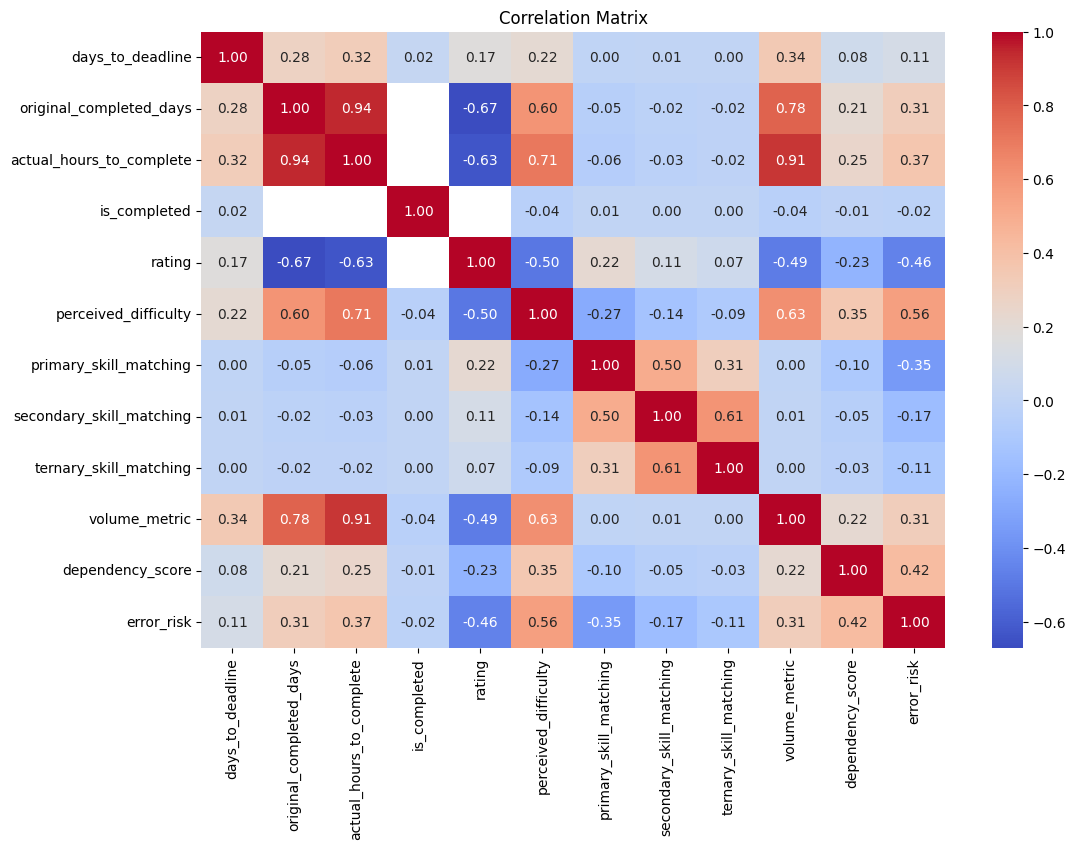

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
rating_corr = correlation_matrix['rating'].sort_values(ascending=False)
rating_corr

,rating
rating,1.000000
primary_skill_matching,0.222620
days_to_deadline,0.174192
secondary_skill_matching,0.110889
ternary_skill_matching,0.068801
dependency_score,-0.231724
error_risk,-0.457284
volume_metric,-0.487366
perceived_difficulty,-0.502486
actual_hours_to_complete,-0.632416


In [ ]:
corr_pairs = correlation_matrix.where(
    ~np.tril(np.ones(correlation_matrix.shape)).astype(bool)
).stack()

corr_pairs = corr_pairs.sort_values(
    key=abs,
    ascending=False
)

corr_pairs

,,0
original_completed_days,actual_hours_to_complete,0.942723
actual_hours_to_complete,volume_metric,0.910927
original_completed_days,volume_metric,0.779107
actual_hours_to_complete,perceived_difficulty,0.709262
original_completed_days,rating,-0.670249
...,...,...
is_completed,ternary_skill_matching,0.003138
ternary_skill_matching,volume_metric,0.002735
days_to_deadline,ternary_skill_matching,0.002218
primary_skill_matching,volume_metric,0.001562


In [ ]:
print("Employees:", employee['employee_id'].nunique())
print("Tasks:", employee['task_id'].nunique())

Employees: 20
Tasks: 200000


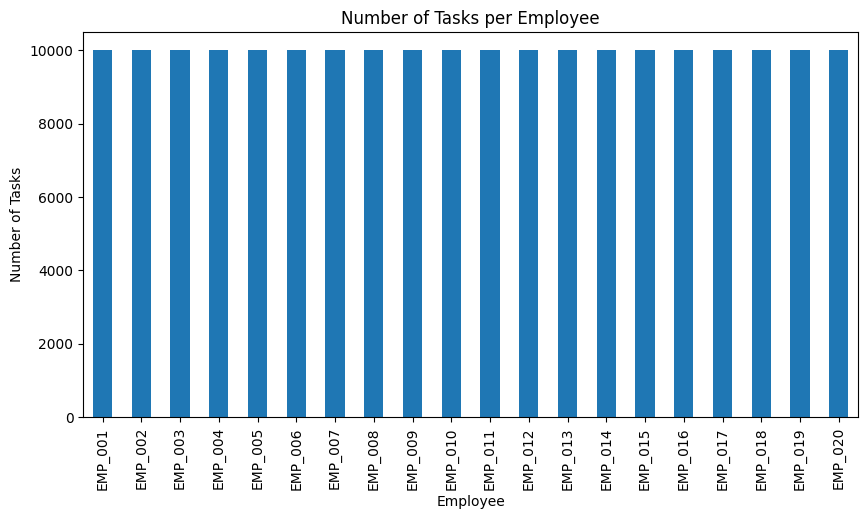

In [ ]:
employee['employee_id'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Number of Tasks per Employee')
plt.xlabel('Employee')
plt.ylabel('Number of Tasks')
plt.show()

In [ ]:
for col in employee.columns:
    print(col)
    print(employee[col].value_counts(dropna=False).head(10))
    print()

employee_id
employee_id
EMP_001    10000
EMP_002    10000
EMP_003    10000
EMP_004    10000
EMP_005    10000
EMP_006    10000
EMP_007    10000
EMP_008    10000
EMP_009    10000
EMP_010    10000
Name: count, dtype: int64

task_id
task_id
TSK_0199984    1
TSK_0199983    1
TSK_0199982    1
TSK_0199981    1
TSK_0199980    1
TSK_0199979    1
TSK_0199978    1
TSK_0199977    1
TSK_0199976    1
TSK_0199975    1
Name: count, dtype: int64

task_type
task_type
Bug Fix                49980
Code Review            40077
Feature Development    39782
Documentation          30064
Data Pipeline          20224
System Maintenance     19873
Name: count, dtype: int64

task_given_date
task_given_date
2025-12-27    271
2025-05-01    269
2026-05-18    268
2025-03-02    266
2024-06-12    266
2024-11-18    265
2025-12-24    264
2025-10-20    264
2026-01-13    262
2025-12-22    261
Name: count, dtype: int64

days_to_deadline
days_to_deadline
16    14821
15    14606
14    13460
13    13134
12    12526
17    12500


In [ ]:
missing = employee.isna().sum()
missing_percent = employee.isna().mean() * 100

missing_table = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
})

missing_table

,Missing Count,Missing Percentage
employee_id,0,0.0000
task_id,0,0.0000
task_type,0,0.0000
task_given_date,0,0.0000
days_to_deadline,0,0.0000
priority,0,0.0000
original_completed_days,44409,22.2045
actual_hours_to_complete,44409,22.2045
is_completed,0,0.0000
rating,44409,22.2045


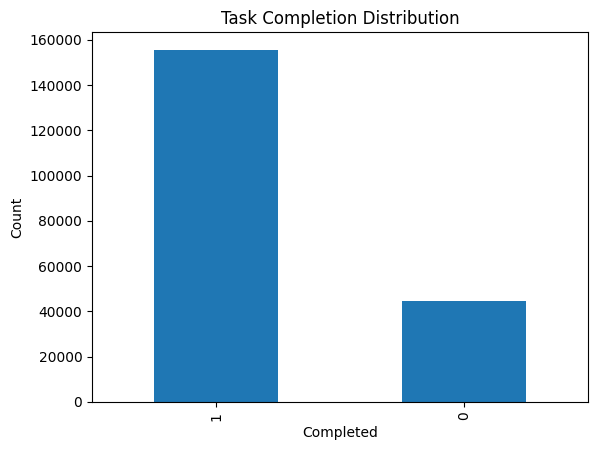

In [ ]:
employee['is_completed'].value_counts(normalize=True) * 100

employee['is_completed'].value_counts().plot(kind='bar')
plt.title('Task Completion Distribution')
plt.xlabel('Completed')
plt.ylabel('Count')
plt.show()

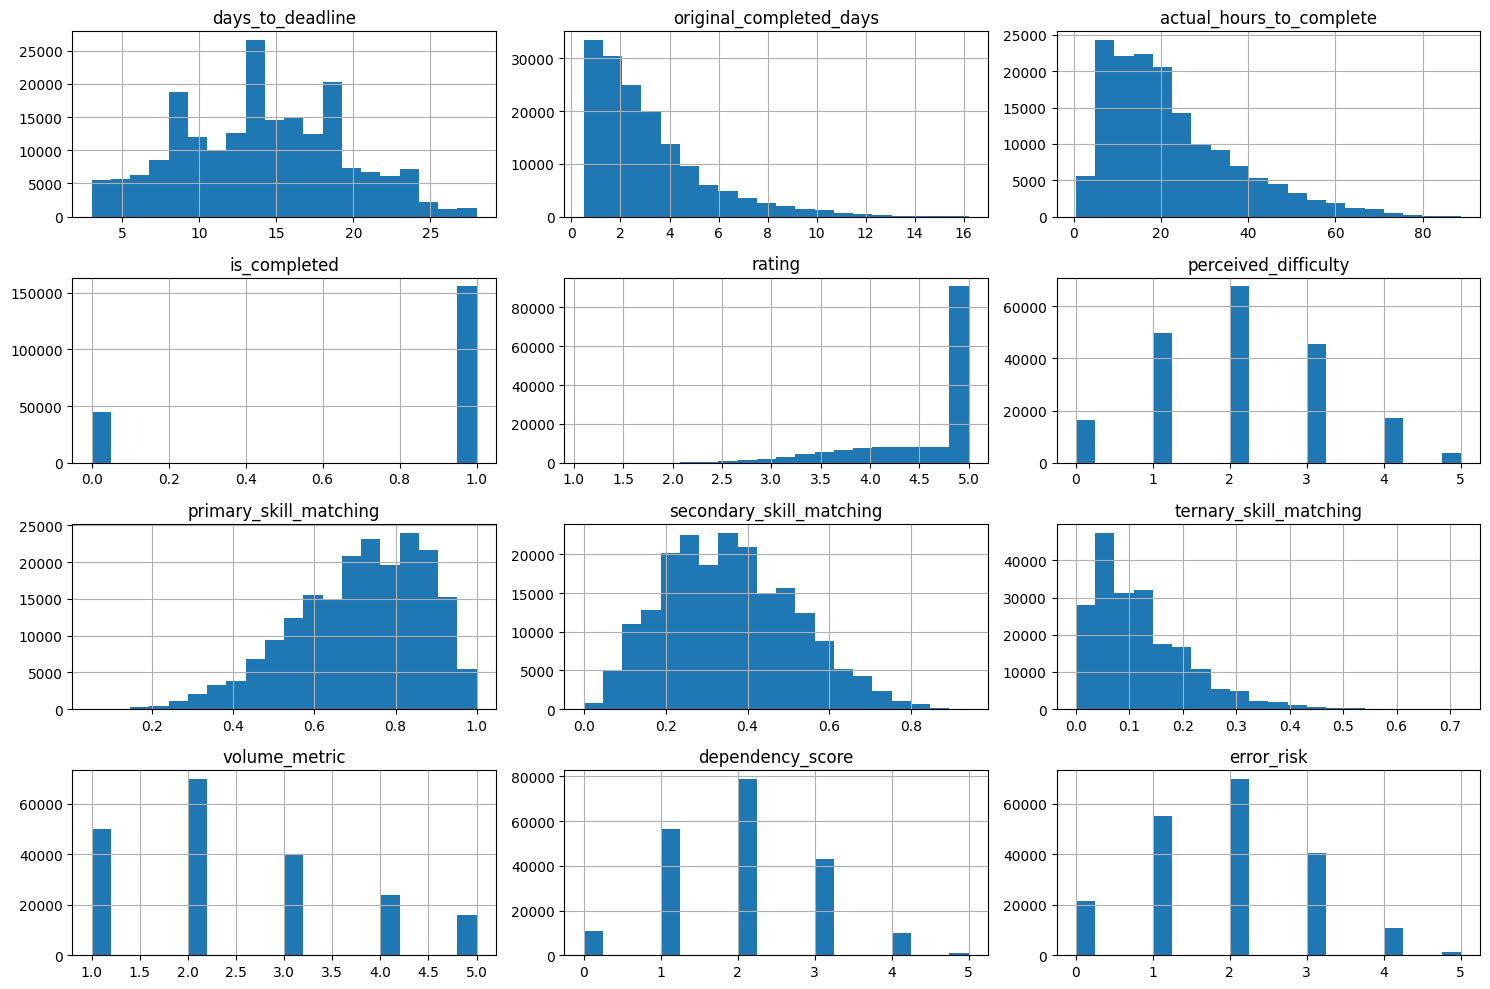

In [ ]:
employee.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

In [ ]:
employee['rating'].value_counts(dropna=False)

,count
rating,
5.0,87057
NaN,44409
4.5,4192
4.3,4188
4.4,4187
4.2,4114
4.7,4044
4.6,4025
4.8,3982


In [ ]:
employee["rating"].describe()

,rating
count,155591.000000
mean,4.572395
std,0.626254
min,1.100000
25%,4.200000
50%,5.000000
75%,5.000000
max,5.000000


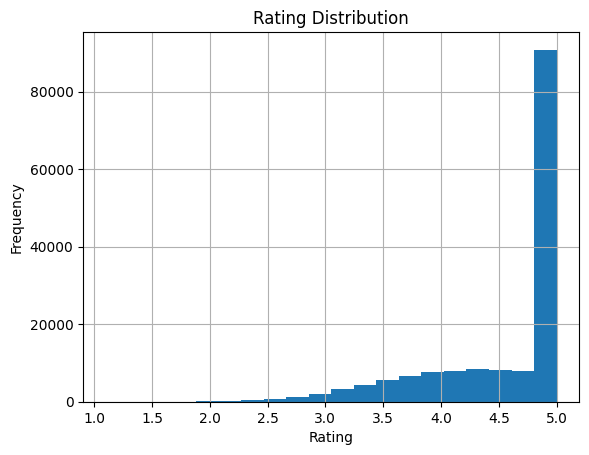

In [ ]:
employee['rating'].hist(bins=20)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

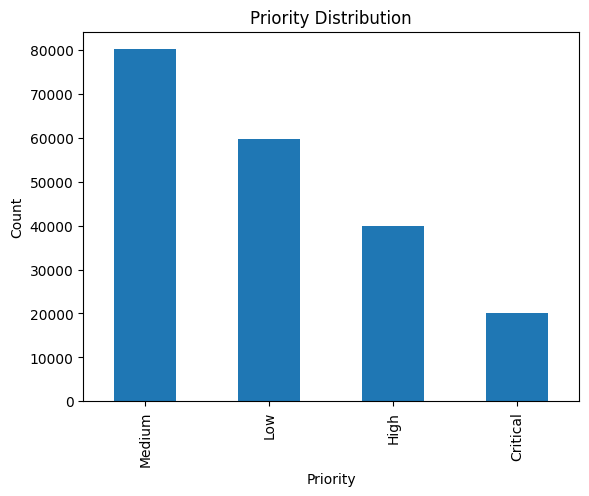

In [ ]:
employee['priority'].value_counts().plot(kind='bar')

plt.title('Priority Distribution')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.show()

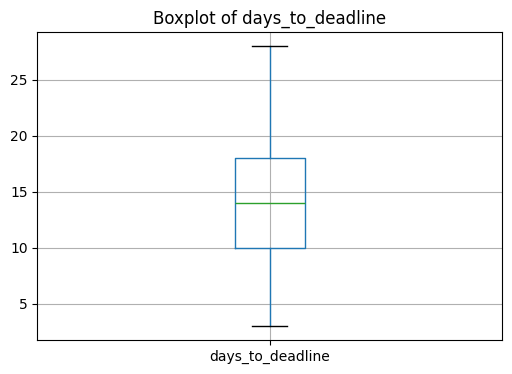

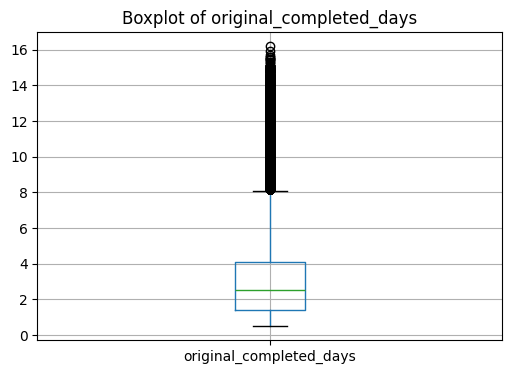

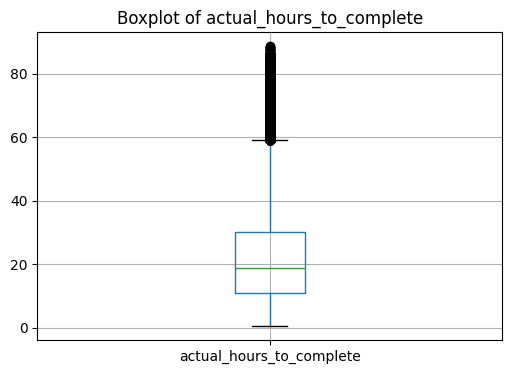

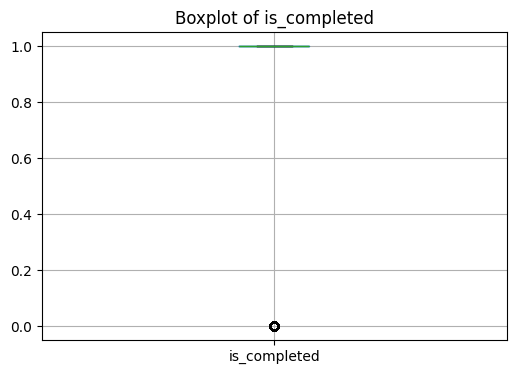

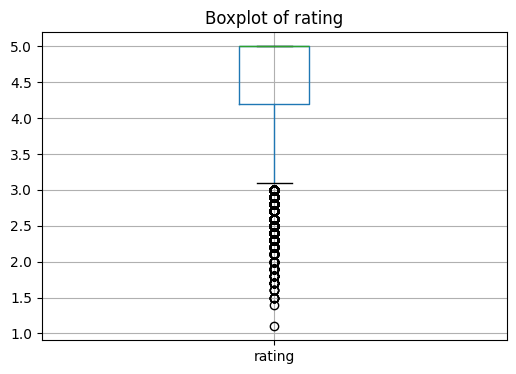

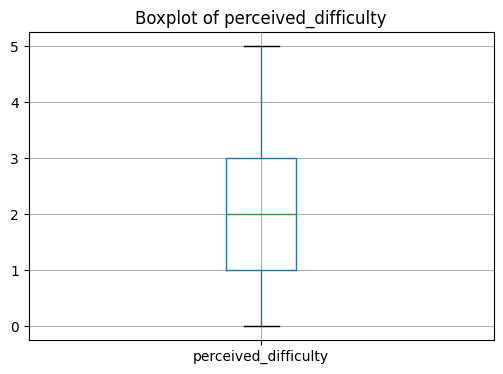

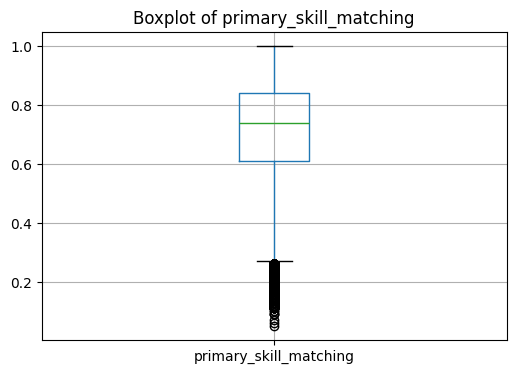

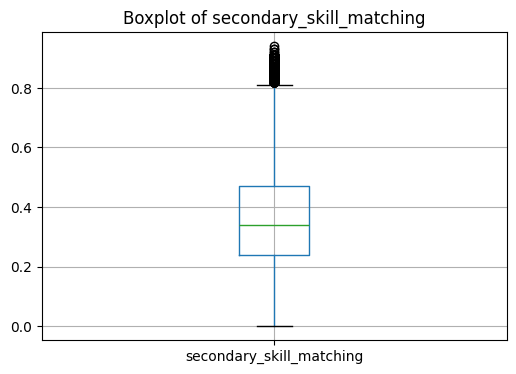

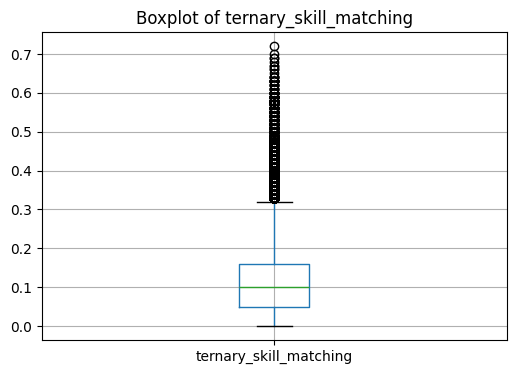

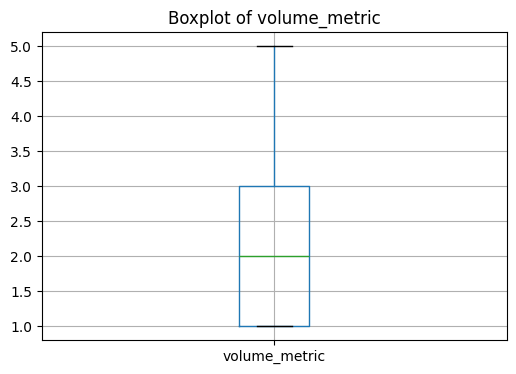

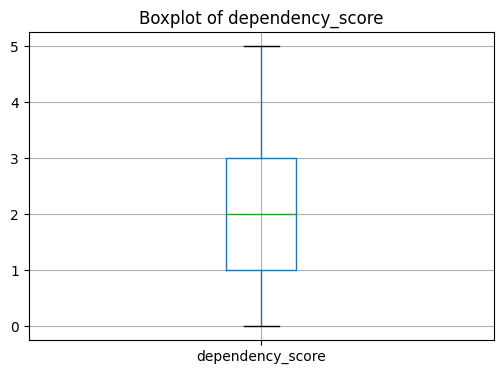

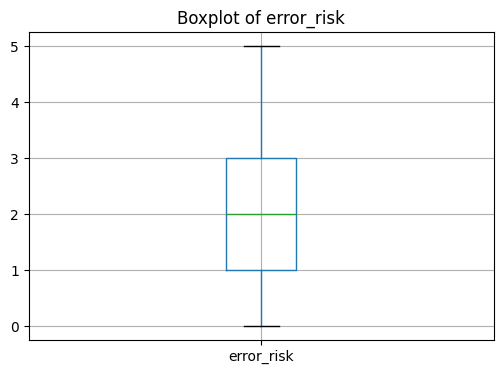

In [ ]:
numerical_cols = employee.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    employee.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

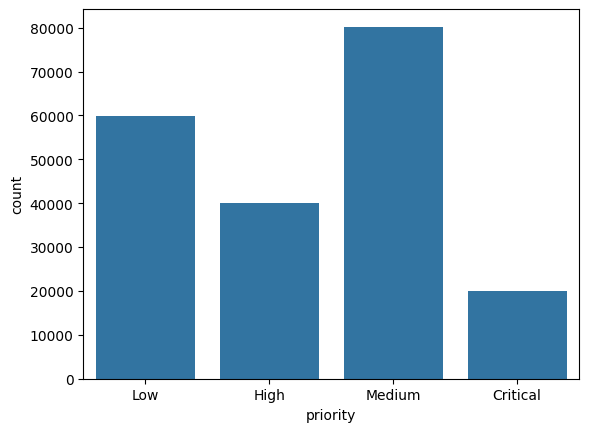

In [ ]:
sns.countplot(data=employee, x='priority')
plt.show()

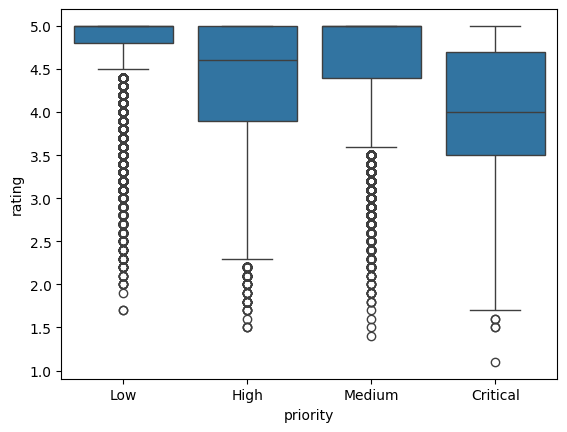

In [ ]:
sns.boxplot(data=employee, x='priority', y='rating')
plt.show()